# Hierarchical Concept-Based Explainable-by-Design Models
## Phase 1 - Baseline CBM (Concept Bottleneck Model)

Standard flat CBM on CUB-200-2011 using **all 312 attributes** and the
full train/test split from the original dataset.

**Pipeline**: Image -> ResNet-50 -> 312 concept scores -> 200 class logits

**Metrics saved**: top-1/5 accuracy, per-concept accuracy, LCA mistake severity.

---
## Cell 1 - Install dependencies

In [ ]:
!pip install torch torchvision matplotlib seaborn pandas numpy Pillow tqdm --quiet
print('Dependencies ready.')

Dependencies ready.


In [ ]:
import random
import numpy as np
import torch
import os

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f'Seed fissato a {SEED} — risultati riproducibili.')
print('Esegui questa cella PRIMA di qualsiasi altra per garantire la riproducibilita.')

Seed fissato a 42 — risultati riproducibili.
Esegui questa cella PRIMA di qualsiasi altra per garantire la riproducibilita.


---
## Cell 2 - Download CUB-200-2011

Re-run this cell whenever the Colab session resets.

In [ ]:
import os, urllib.request, tarfile

DATA_DIR = '/content/data'
CUB_DIR  = os.path.join(DATA_DIR, 'CUB_200_2011')
CUB_URL  = 'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz'
CUB_TGZ  = os.path.join(DATA_DIR, 'CUB_200_2011.tgz')
SAVE_DIR = '/content/processed'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

if not os.path.exists(CUB_DIR):
    print('Downloading CUB-200-2011 (~1.1 GB)...')
    # Create a Request object with a User-Agent header
    req = urllib.request.Request(CUB_URL, headers={'User-Agent': 'Mozilla/5.0'})
    # Open the URL with the request object and save the content
    with urllib.request.urlopen(req) as response:
        with open(CUB_TGZ, 'wb') as out_file:
            out_file.write(response.read())

    print('Extracting...')
    with tarfile.open(CUB_TGZ, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    print('Done.')
else:
    print('CUB already present.')

print('\nCUB root contents:')
for f in sorted(os.listdir(CUB_DIR)):
    print(' ', f)

Extracting...


/tmp/ipykernel_476/2061009045.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done.

CUB root contents:
  README
  attributes
  bounding_boxes.txt
  classes.txt
  image_class_labels.txt
  images
  images.txt
  parts
  train_test_split.txt


In [ ]:
# move /content/data/attributes.txt in /content/data/CUB_200_2011/attributes
!mv /content/data/attributes.txt /content/data/CUB_200_2011/attributes

---
## Cell 3 - Load all annotation files

We use **all 312 attributes** with no filtering.
The only quality filter applied is `certainty >= 3` (annotator was
at least 'probably sure'), which is the standard practice in CUB.

In [ ]:
import pandas as pd
import numpy as np
import os

def load_txt(filename, col_names, sep=' '):
    return pd.read_csv(os.path.join(CUB_DIR, filename),
                       sep=sep, header=None, names=col_names)

images_df  = load_txt('images.txt',             ['img_id', 'filepath'])
labels_df  = load_txt('image_class_labels.txt', ['img_id', 'class_id'])
split_df   = load_txt('train_test_split.txt',   ['img_id', 'is_train'])
classes_df = load_txt('classes.txt',            ['class_id', 'class_name'])
attrs_df   = load_txt('attributes/attributes.txt', ['attr_id', 'attr_name'])

# Use numpy.loadtxt for image_attribute_labels.txt due to persistent parsing issues
# Specify usecols to only read the first 5 columns, ignoring any unexpected extra columns
img_attr_data = np.loadtxt(
    os.path.join(CUB_DIR, 'attributes/image_attribute_labels.txt'),
    dtype=int,
    usecols=range(5) # Select only the first 5 columns
)
img_attr_df = pd.DataFrame(img_attr_data,
    columns=['img_id', 'attr_id', 'is_present', 'certainty', 'time']
)

master_df = (
    images_df
    .merge(labels_df,  on='img_id')
    .merge(split_df,   on='img_id')
    .merge(classes_df, on='class_id')
)

# Parse part groups from attribute names  (format: 'part::descriptor')
attrs_df[['part', 'descriptor']] = attrs_df['attr_name'].str.split('::', expand=True)

print(f'Total images  : {len(master_df)}')
print(f'Train images  : {master_df.is_train.sum()}')
print(f'Test  images  : {(~master_df.is_train.astype(bool)).sum()}')
print(f'Classes       : {master_df.class_id.nunique()}')
print(f'Attributes    : {len(attrs_df)}')

N_CONCEPTS = len(attrs_df)   # 312
N_CLASSES  = 200
print(f'N_CONCEPTS={N_CONCEPTS}  N_CLASSES={N_CLASSES}')

/tmp/ipykernel_476/3810591067.py:17: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  img_attr_data = np.loadtxt(


Total images  : 11788
Train images  : 5994
Test  images  : 5794
Classes       : 200
Attributes    : 312
N_CONCEPTS=312  N_CLASSES=200


In [ ]:
attrs_df.head()

,attr_id,attr_name,part,descriptor
0,1,has_bill_shape::curved_(up_or_down),has_bill_shape,curved_(up_or_down)
1,2,has_bill_shape::dagger,has_bill_shape,dagger
2,3,has_bill_shape::hooked,has_bill_shape,hooked
3,4,has_bill_shape::needle,has_bill_shape,needle
4,5,has_bill_shape::hooked_seabird,has_bill_shape,hooked_seabird


---
## Cell 4 - Build the concept matrix

We pivot the annotation table into a `(num_images, 312)` binary matrix.
Only annotations with `certainty >= 3` are kept; the rest default to 0.

In [ ]:
CERTAINTY_THRESHOLD = 3

img_attr_filtered = img_attr_df[
    img_attr_df['certainty'] >= CERTAINTY_THRESHOLD
].copy()

concept_matrix = img_attr_filtered.pivot_table(
    index='img_id', columns='attr_id',
    values='is_present', fill_value=0
).astype(np.float32)

# Ensure all 312 columns are present and in sorted order
all_attr_ids = sorted(attrs_df['attr_id'].tolist())
concept_matrix = concept_matrix.reindex(columns=all_attr_ids, fill_value=0)

print(f'Concept matrix shape : {concept_matrix.shape}  (images x attributes)')
print(f'Sparsity             : {(concept_matrix == 0).mean().mean():.1%} zeros')
print(f'Mean presence rate   : {concept_matrix.mean().mean():.3f}')

# Save for later phases
attrs_df.to_csv(os.path.join(SAVE_DIR, 'attrs_312.csv'), index=False)
classes_df.to_csv(os.path.join(SAVE_DIR, 'classes_df.csv'), index=False)
master_df.to_csv(os.path.join(SAVE_DIR, 'master_df.csv'), index=False)
concept_matrix.to_csv(os.path.join(SAVE_DIR, 'concept_matrix_312.csv'))
print('Saved attrs_312.csv, classes_df.csv, master_df.csv, concept_matrix_312.csv')

Concept matrix shape : (11455, 312)  (images x attributes)
Sparsity             : 90.4% zeros
Mean presence rate   : 0.096
Saved attrs_312.csv, classes_df.csv, master_df.csv, concept_matrix_312.csv


In [ ]:
concept_matrix.shape

(11455, 312)

---
## Cell 5 - Concept distribution analysis

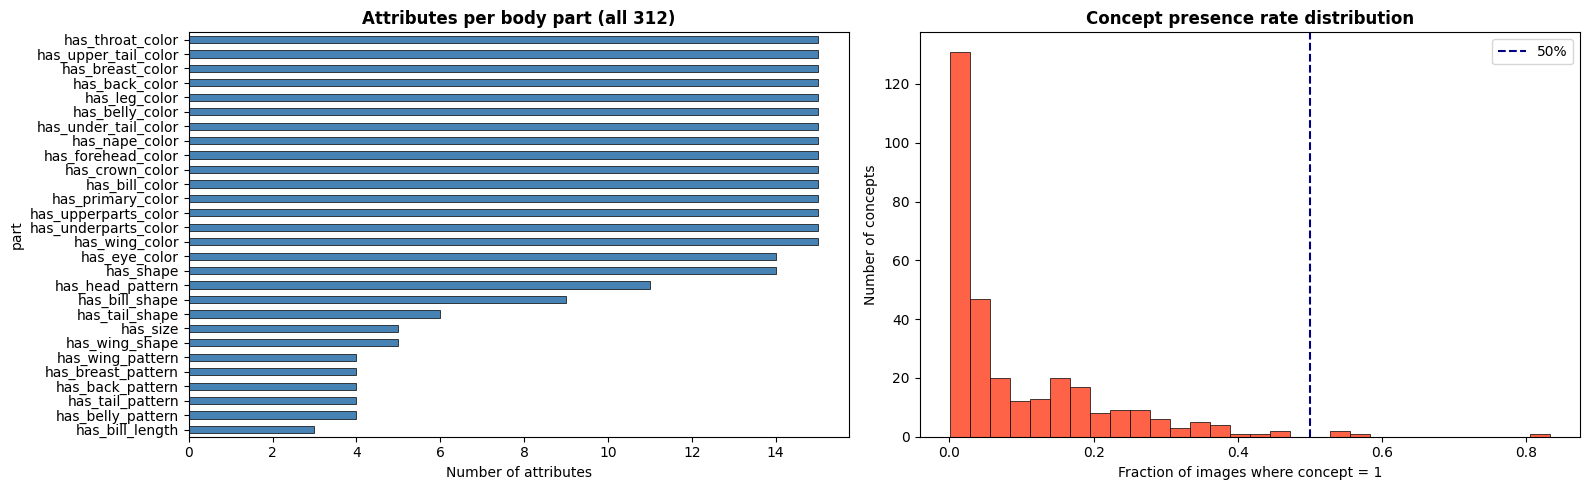

Presence rate  mean=0.096  min=0.000  max=0.833


In [ ]:
import matplotlib.pyplot as plt

part_counts   = attrs_df['part'].value_counts()
presence_rate = concept_matrix.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

part_counts.sort_values().plot(
    kind='barh', ax=axes[0],
    color='steelblue', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Attributes per body part (all 312)', fontweight='bold')
axes[0].set_xlabel('Number of attributes')

axes[1].hist(presence_rate.values, bins=30,
             color='tomato', edgecolor='black', linewidth=0.5)
axes[1].axvline(0.5, color='navy', linestyle='--', label='50%')
axes[1].set_title('Concept presence rate distribution', fontweight='bold')
axes[1].set_xlabel('Fraction of images where concept = 1')
axes[1].set_ylabel('Number of concepts')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'attr_analysis.png'), dpi=150)
plt.show()
print(f'Presence rate  mean={presence_rate.mean():.3f}  min={presence_rate.min():.3f}  max={presence_rate.max():.3f}')

---
## Cell 6 - CUBDataset (PyTorch)

Returns `(image_tensor, concept_vector_312, class_label_0indexed)` per sample.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class CUBDataset(Dataset):
    def __init__(self, master_df, concept_matrix, cub_dir, split='train', transform=None):
        self.df = (
            master_df[master_df['is_train'] == int(split == 'train')]
            .copy().reset_index(drop=True)
        )
        self.concept_matrix = concept_matrix
        self.cub_dir        = cub_dir
        self.transform      = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row['img_id']

        image = Image.open(
            os.path.join(self.cub_dir, 'images', row['filepath'])
        ).convert('RGB')
        if self.transform:
            image = self.transform(image)

        if img_id in self.concept_matrix.index:
            concepts = torch.tensor(
                self.concept_matrix.loc[img_id].values, dtype=torch.float32
            )
        else:
            concepts = torch.zeros(self.concept_matrix.shape[1], dtype=torch.float32)

        label = int(row['class_id']) - 1   # 0-indexed
        return image, concepts, label


BATCH_SIZE  = 64
NUM_WORKERS = 2

train_dataset = CUBDataset(master_df, concept_matrix, CUB_DIR, 'train', train_transform)
test_dataset  = CUBDataset(master_df, concept_matrix, CUB_DIR, 'test',  test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_loader)} batches  ({len(train_dataset)} images)')
print(f'Test : {len(test_loader)} batches   ({len(test_dataset)} images)')
imgs, concepts, labels = next(iter(train_loader))
print(f'Batch  image:{imgs.shape}  concepts:{concepts.shape}  labels:{labels.shape}')

Train: 94 batches  (5994 images)
Test : 91 batches   (5794 images)
Batch  image:torch.Size([64, 3, 224, 224])  concepts:torch.Size([64, 312])  labels:torch.Size([64])


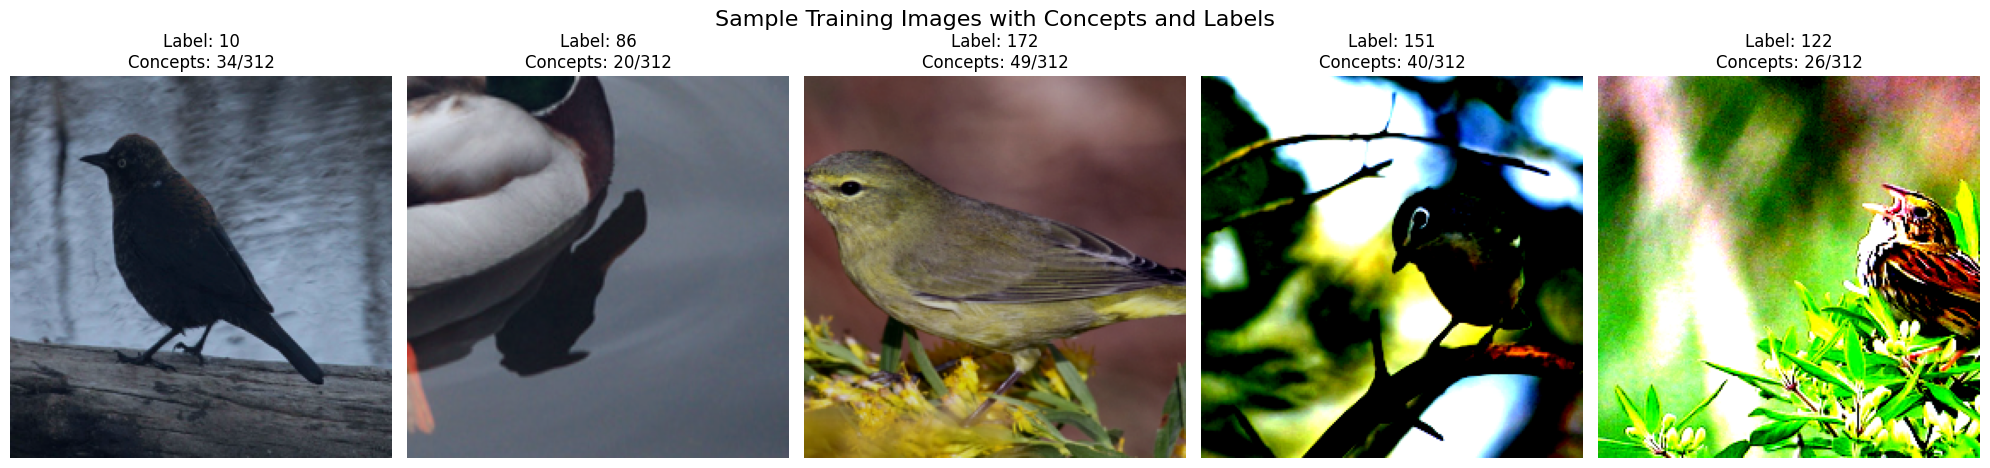


Concepts for the first image:
- has_bill_shape::all-purpose
- has_wing_color::brown
- has_wing_color::black
- has_upperparts_color::black
- has_underparts_color::black
... and 29 more.


In [ ]:
import matplotlib.pyplot as plt

# Get 5 samples from the train_loader
imgs, concepts, labels = next(iter(train_loader))

# Inverse normalize images for display
def inverse_normalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Select the first 5 images, concepts, and labels
selected_imgs     = imgs[:5]
selected_concepts = concepts[:5]
selected_labels   = labels[:5]

# Inverse normalize the selected images
selected_imgs = inverse_normalize(selected_imgs, IMAGENET_MEAN, IMAGENET_STD)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    # Convert image tensor to numpy array for display
    img_np = selected_imgs[i].permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1) # Clip values to [0, 1] in case of slight out-of-range due to normalization

    axes[i].imshow(img_np)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {selected_labels[i].item()}\nConcepts: {selected_concepts[i].sum().item():.0f}/{N_CONCEPTS}")

plt.suptitle('Sample Training Images with Concepts and Labels', fontsize=16)
plt.tight_layout()
plt.show()

# Show 5 concepts for the first image
print('\nConcepts for the first image:')
first_image_concepts_indices = (selected_concepts[0] == 1).nonzero(as_tuple=True)[0]
if len(first_image_concepts_indices) > 0:
    # Map indices back to original attr_id (which is 1-indexed)
    concept_ids = [attrs_df.loc[idx, 'attr_id'] for idx in first_image_concepts_indices.cpu().numpy()]
    # Get concept names, assuming attrs_df is 0-indexed corresponding to 1-indexed attr_id
    # Adjusting for attrs_df being 0-indexed for .loc (but attr_id col is 1-indexed in data)
    concept_names = [attrs_df[attrs_df['attr_id'] == cid]['attr_name'].iloc[0] for cid in concept_ids]
    for j, concept_name in enumerate(concept_names[:5]):
        print(f"- {concept_name}")
    if len(concept_names) > 5:
        print(f"... and {len(concept_names) - 5} more.")
else:
    print("No concepts present for the first image.")

---
## Cell 7 - CBM Architecture

Stage 1: ResNet-50 pretrained -> Linear(2048, 312) -> Sigmoid -> 312 concept scores
Stage 2: 312 concept scores   -> Linear(312,  200) -> 200 class logits

Loss = lambda * BCE(concepts) + CrossEntropy(labels)

In [ ]:
import torch.nn as nn
from torchvision import models


class ConceptBottleneckModel(nn.Module):
    def __init__(self, n_concepts=312, n_classes=200):
        super().__init__()
        backbone    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        backbone.fc = nn.Linear(backbone.fc.in_features, n_concepts)
        self.backbone        = backbone
        self.sigmoid         = nn.Sigmoid()
        self.label_predictor = nn.Linear(n_concepts, n_classes)

    def forward(self, x, return_concepts=False):
        concept_probs = self.sigmoid(self.backbone(x))
        logits        = self.label_predictor(concept_probs)
        if return_concepts:
            return logits, concept_probs
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ConceptBottleneckModel(N_CONCEPTS, N_CLASSES).to(device)
print(f'Device          : {device}')
print(f'N_CONCEPTS      : {N_CONCEPTS}')
print(f'N_CLASSES       : {N_CLASSES}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 205MB/s]


Device          : cuda
N_CONCEPTS      : 312
N_CLASSES       : 200
Trainable params: 24,209,920


---
## Cell 8 - Loss, optimiser, scheduler

In [ ]:
import torch.optim as optim

concept_criterion = nn.BCELoss()
label_criterion   = nn.CrossEntropyLoss()
LAMBDA_CONCEPT    = 1.0

optimizer = optim.Adam([
    {'params': model.backbone.parameters(),        'lr': 1e-4},
    {'params': model.label_predictor.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

N_EPOCHS = 30
print(f'Optimizer : Adam  backbone=1e-4  head=1e-3  wd=1e-4')
print(f'Scheduler : ReduceLROnPlateau  patience=3  factor=0.5')
print(f'Loss      : {LAMBDA_CONCEPT} x BCE(concepts) + 1.0 x CE(labels)')
print(f'Epochs    : {N_EPOCHS}')

Optimizer : Adam  backbone=1e-4  head=1e-3  wd=1e-4
Scheduler : ReduceLROnPlateau  patience=3  factor=0.5
Loss      : 1.0 x BCE(concepts) + 1.0 x CE(labels)
Epochs    : 30


---
## Cell 9 - Training and evaluation helpers

In [ ]:
from tqdm import tqdm


def train_one_epoch(model, loader, optimizer, device, lambda_concept=1.0):
    model.train()
    tot_loss = tot_c = tot_l = correct = total = 0
    for images, concepts_gt, labels in tqdm(loader, desc='  train', leave=False):
        images      = images.to(device)
        concepts_gt = concepts_gt.to(device)
        labels      = labels.to(device)
        optimizer.zero_grad()
        logits, concept_probs = model(images, return_concepts=True)
        c_loss = concept_criterion(concept_probs, concepts_gt)
        l_loss = label_criterion(logits, labels)
        loss   = lambda_concept * c_loss + l_loss
        loss.backward()
        optimizer.step()
        n         = images.size(0)
        tot_loss += loss.item()   * n
        tot_c    += c_loss.item() * n
        tot_l    += l_loss.item() * n
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += n
    nd = len(loader.dataset)
    return {
        'loss': tot_loss/nd, 'concept_loss': tot_c/nd,
        'label_loss': tot_l/nd, 'accuracy': correct/total
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    tot_loss = tot_c = tot_l = correct1 = correct5 = total = 0
    concept_correct = torch.zeros(N_CONCEPTS)
    concept_total   = torch.zeros(N_CONCEPTS)
    all_preds, all_labels = [], []
    for images, concepts_gt, labels in tqdm(loader, desc='  eval ', leave=False):
        images      = images.to(device)
        concepts_gt = concepts_gt.to(device)
        labels      = labels.to(device)
        logits, concept_probs = model(images, return_concepts=True)
        c_loss = concept_criterion(concept_probs, concepts_gt)
        l_loss = label_criterion(logits, labels)
        loss   = LAMBDA_CONCEPT * c_loss + l_loss
        n         = images.size(0)
        tot_loss += loss.item()   * n
        tot_c    += c_loss.item() * n
        tot_l    += l_loss.item() * n
        top5      = logits.topk(5, dim=1).indices
        correct1 += (top5[:, 0] == labels).sum().item()
        correct5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()
        total    += n
        cp = (concept_probs.cpu() >= 0.5).float()
        concept_correct += (cp == concepts_gt.cpu()).sum(dim=0)
        concept_total   += n
        all_preds.extend(top5[:, 0].cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    nd = len(loader.dataset)
    return {
        'loss': tot_loss/nd, 'concept_loss': tot_c/nd, 'label_loss': tot_l/nd,
        'top1_accuracy': correct1/total, 'top5_accuracy': correct5/total,
        'concept_accuracy': (concept_correct/concept_total).numpy(),
        'preds': all_preds, 'labels': all_labels,
    }

print('Helpers ready: train_one_epoch(), evaluate()')

Helpers ready: train_one_epoch(), evaluate()


---
## Cell 10 - Training loop

In [ ]:
import json

history    = []
best_top1  = 0.0
best_epoch = 0
CKPT_PATH  = os.path.join(SAVE_DIR, 'baseline_cbm_best.pt')

for epoch in range(1, N_EPOCHS + 1):
    print(f'Epoch {epoch}/{N_EPOCHS}')
    train_m = train_one_epoch(model, train_loader, optimizer, device, LAMBDA_CONCEPT)
    test_m  = evaluate(model, test_loader, device)
    scheduler.step(test_m['top1_accuracy'])
    if test_m['top1_accuracy'] > best_top1:
        best_top1, best_epoch = test_m['top1_accuracy'], epoch
        torch.save(model.state_dict(), CKPT_PATH)
    record = {
        'epoch':           epoch,
        'train_loss':      train_m['loss'],
        'train_acc':       train_m['accuracy'],
        'test_loss':       test_m['loss'],
        'test_top1':       test_m['top1_accuracy'],
        'test_top5':       test_m['top5_accuracy'],
        'mean_concept_acc': float(test_m['concept_accuracy'].mean()),
    }
    history.append(record)
    print(
        f'  train loss={train_m["loss"]:.4f} acc={train_m["accuracy"]:.3f} |'
        f' test top1={test_m["top1_accuracy"]:.3f}'
        f' top5={test_m["top5_accuracy"]:.3f}'
        f' concept={test_m["concept_accuracy"].mean():.3f}'
        f' [best={best_top1:.3f} @ep{best_epoch}]'
    )

with open(os.path.join(SAVE_DIR, 'baseline_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print(f'Done. Best top-1: {best_top1:.4f} at epoch {best_epoch}')

Epoch 1/30


  train loss=5.5945 acc=0.013 | test top1=0.049 top5=0.190 concept=0.889 [best=0.049 @ep1]
Epoch 2/30


  train loss=5.0410 acc=0.048 | test top1=0.109 top5=0.361 concept=0.825 [best=0.109 @ep2]
Epoch 3/30


  train loss=4.3642 acc=0.111 | test top1=0.188 top5=0.534 concept=0.799 [best=0.188 @ep3]
Epoch 4/30


  train loss=3.8026 acc=0.201 | test top1=0.298 top5=0.689 concept=0.776 [best=0.298 @ep4]
Epoch 5/30


...

  train loss=1.1906 acc=0.816 | test top1=0.743 top5=0.940 concept=0.800 [best=0.755 @ep24]
Epoch 27/30


  train loss=1.1755 acc=0.822 | test top1=0.764 top5=0.942 concept=0.809 [best=0.764 @ep27]
Epoch 28/30


  train loss=1.1162 acc=0.833 | test top1=0.757 top5=0.941 concept=0.804 [best=0.764 @ep27]
Epoch 29/30


  train loss=1.1039 acc=0.838 | test top1=0.763 top5=0.945 concept=0.805 [best=0.764 @ep27]
Epoch 30/30


  train loss=1.0895 acc=0.844 | test top1=0.755 top5=0.939 concept=0.812 [best=0.764 @ep27]
Done. Best top-1: 0.7635 at epoch 27


---
## Cell 11 - Load best checkpoint and final evaluation

In [ ]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
final = evaluate(model, test_loader, device)

print('=' * 55)
print('BASELINE CBM - Final Test Results')
print('=' * 55)
print(f'  Top-1 Accuracy       : {final["top1_accuracy"]:.4f}  ({final["top1_accuracy"]*100:.2f}%)')
print(f'  Top-5 Accuracy       : {final["top5_accuracy"]:.4f}  ({final["top5_accuracy"]*100:.2f}%)')
print(f'  Mean Concept Accuracy: {final["concept_accuracy"].mean():.4f}')
print(f'  Min  Concept Accuracy: {final["concept_accuracy"].min():.4f}')
print(f'  Max  Concept Accuracy: {final["concept_accuracy"].max():.4f}')

final_save = {
    'model':            'baseline_cbm',
    'n_concepts':       N_CONCEPTS,
    'top1_accuracy':    final['top1_accuracy'],
    'top5_accuracy':    final['top5_accuracy'],
    'mean_concept_acc': float(final['concept_accuracy'].mean()),
    'per_concept_acc':  final['concept_accuracy'].tolist(),
    'preds':            final['preds'],
    'labels':           final['labels'],
}
with open(os.path.join(SAVE_DIR, 'baseline_final_metrics.json'), 'w') as f:
    json.dump(final_save, f, indent=2)
print('Saved baseline_final_metrics.json')

BASELINE CBM - Final Test Results
  Top-1 Accuracy       : 0.7635  (76.35%)
  Top-5 Accuracy       : 0.9420  (94.20%)
  Mean Concept Accuracy: 0.8094
  Min  Concept Accuracy: 0.5808
  Max  Concept Accuracy: 0.9998
Saved baseline_final_metrics.json


---
## Cell 12 - Training curves

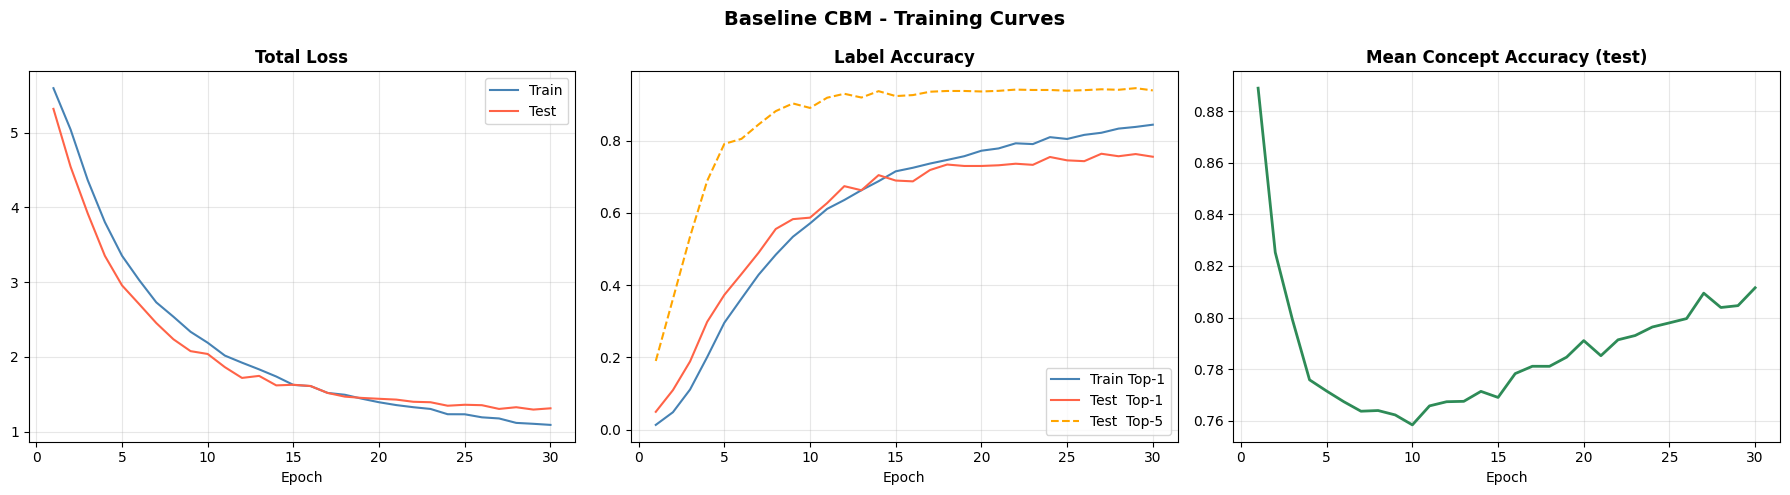

In [ ]:
epochs      = [r['epoch']           for r in history]
train_loss  = [r['train_loss']      for r in history]
test_loss   = [r['test_loss']       for r in history]
train_acc   = [r['train_acc']       for r in history]
test_top1   = [r['test_top1']       for r in history]
test_top5   = [r['test_top5']       for r in history]
concept_acc = [r['mean_concept_acc']for r in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, train_loss, label='Train', color='steelblue')
axes[0].plot(epochs, test_loss,  label='Test',  color='tomato')
axes[0].set_title('Total Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_acc, label='Train Top-1', color='steelblue')
axes[1].plot(epochs, test_top1, label='Test  Top-1', color='tomato')
axes[1].plot(epochs, test_top5, label='Test  Top-5', color='orange', linestyle='--')
axes[1].set_title('Label Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, concept_acc, color='seagreen', linewidth=2)
axes[2].set_title('Mean Concept Accuracy (test)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.suptitle('Baseline CBM - Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'baseline_training_curves.png'), dpi=150)
plt.show()

---
## Cell 13 - Per-concept accuracy

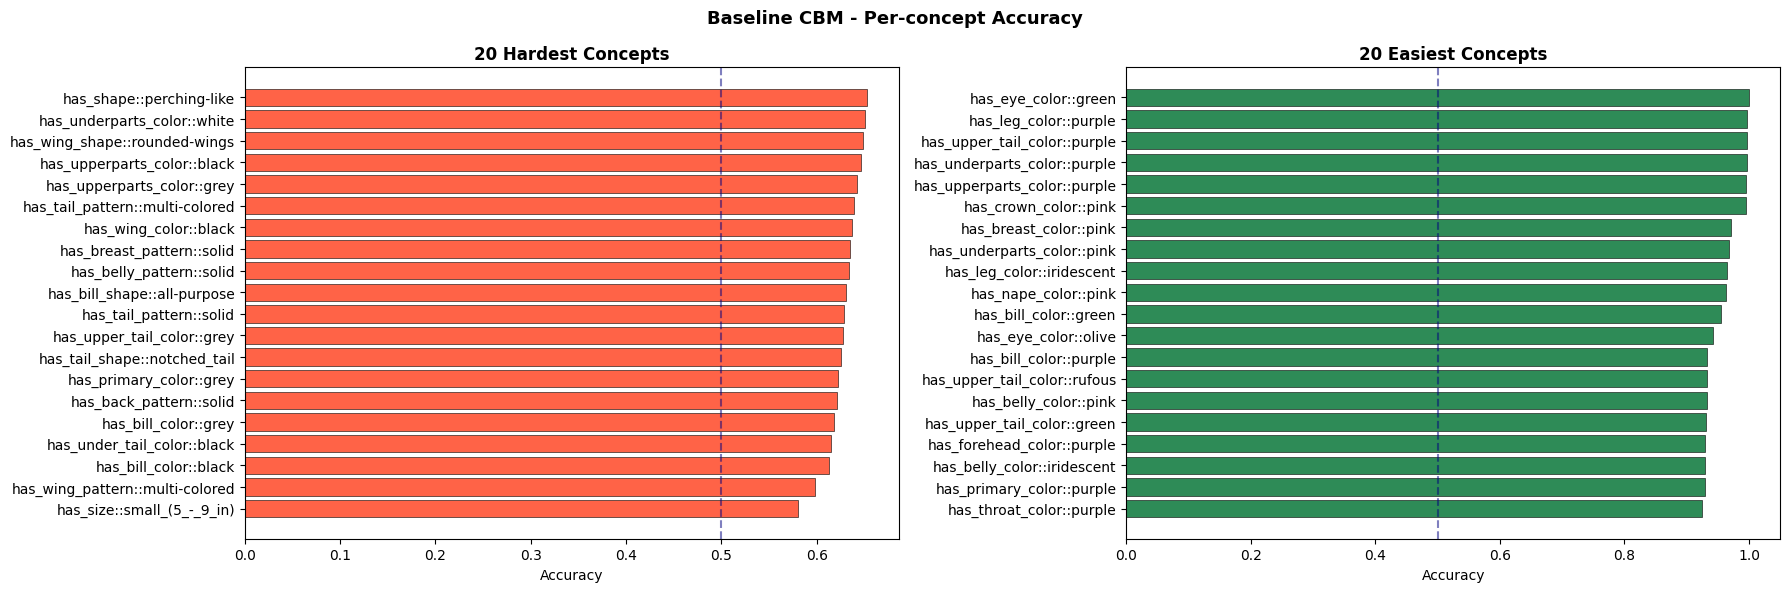

Mean accuracy by body part:
part
has_wing_pattern        0.697575
has_tail_pattern        0.705169
has_back_pattern        0.725751
has_bill_length         0.731331
has_belly_pattern       0.734122
has_breast_pattern      0.735589
has_size                0.744736
has_wing_shape          0.746496
has_tail_shape          0.758112
has_head_pattern        0.783805
has_bill_shape          0.791470
has_upperparts_color    0.799908
has_wing_color          0.801266
has_bill_color          0.806144
has_back_color          0.808687
has_shape               0.812676
has_primary_color       0.815775
has_under_tail_color    0.817708
has_nape_color          0.822725
has_forehead_color      0.823542
has_belly_color         0.824520
has_crown_color         0.825509
has_breast_color        0.826694
has_underparts_color    0.832344
has_throat_color        0.833782
has_upper_tail_color    0.839248
has_leg_color           0.840444
has_eye_color           0.861223


In [ ]:
acc_df = attrs_df.copy()
acc_df['accuracy'] = final['concept_accuracy']
acc_df = acc_df.sort_values('accuracy')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bottom20 = acc_df.head(20)
axes[0].barh(bottom20['attr_name'], bottom20['accuracy'],
             color='tomato', edgecolor='black', linewidth=0.4)
axes[0].set_title('20 Hardest Concepts', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(0.5, color='navy', linestyle='--', alpha=0.5)

top20 = acc_df.tail(20)
axes[1].barh(top20['attr_name'], top20['accuracy'],
             color='seagreen', edgecolor='black', linewidth=0.4)
axes[1].set_title('20 Easiest Concepts', fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].axvline(0.5, color='navy', linestyle='--', alpha=0.5)

plt.suptitle('Baseline CBM - Per-concept Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'baseline_concept_accuracy.png'), dpi=150)
plt.show()

print('Mean accuracy by body part:')
print(acc_df.groupby('part')['accuracy'].mean().sort_values().to_string())

---
## Cell 14 - Baseline LCA mistake severity

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet as wn

SAVE_DIR  = '/content/processed'
CUB_DIR   = '/content/data/CUB_200_2011'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Carica i nomi delle 200 classi ──────────────────────────────────────────
classes_df = pd.read_csv(
    os.path.join(CUB_DIR, 'classes.txt'),
    sep=' ', header=None, names=['class_id', 'class_name']
)

# ── Funzione: trova il synset WordNet per una specie CUB ────────────────────
def get_bird_synset(class_name):
    """
    Da '001.Black_footed_Albatross' estrae il nome della specie
    e cerca il synset WordNet più appropriato.
    """
    raw = class_name.split('.', 1)[-1].lower().replace('_', ' ')
    candidates = [
        raw,  #Black footed Albratoss
        ' '.join(raw.split()[-2:]),   # ultime due parole (genere + specie) footed Albatross
        raw.split()[-1],              # ultima parola sola Albatross
    ]
    for query in candidates:
        synsets = wn.synsets(query.replace(' ', '_'), pos=wn.NOUN)
        for s in synsets:
            hypernyms = set(h.name() for h in s.closure(lambda x: x.hypernyms()))
            if any('bird' in h or 'fowl' in h for h in hypernyms):
                return s
    return None

# ── Funzione: altezza LCA tra due synset ────────────────────────────────────
def lca_height(s1, s2):
    if s1 is None or s2 is None:
        return -1
    lca_list = s1.lowest_common_hypernyms(s2)
    if not lca_list:
        return -1
    return lca_list[0].min_depth()

# ── Mappa class_id -> synset ─────────────────────────────────────────────────
print('Cercando synset WordNet per le 200 specie...')
class_synsets = {}
missing = []
for _, row in classes_df.iterrows():
    s = get_bird_synset(row['class_name'])
    class_synsets[int(row['class_id'])] = s
    if s is None:
        missing.append(row['class_name'])

print(f'Trovati : {len(classes_df) - len(missing)}/{len(classes_df)}')
if missing:
    print(f'Non trovati ({len(missing)}): {missing[:5]}')

# ── Costruisci la matrice LCA 200x200 ────────────────────────────────────────
class_ids = sorted(class_synsets.keys())
n = len(class_ids)
lca_matrix = np.full((n, n), -1, dtype=np.int16)

print('Calcolando la matrice LCA (200x200)...')
for i, ci in enumerate(tqdm(class_ids)):
    for j, cj in enumerate(class_ids):
        if i == j:
            lca_matrix[i, j] = 0
        elif j > i:
            h = lca_height(class_synsets[ci], class_synsets[cj])
            lca_matrix[i, j] = h
            lca_matrix[j, i] = h  # simmetrica

lca_df = pd.DataFrame(lca_matrix, index=class_ids, columns=class_ids)
out_path = os.path.join(SAVE_DIR, 'lca_matrix.csv')
lca_df.to_csv(out_path)

print(f'Salvata: {out_path}')
print(f'Shape  : {lca_df.shape}')
print(f'Coppie valide (LCA >= 0): {(lca_matrix >= 0).sum() - n}')
print(f'Coppie non trovate (LCA = -1): {(lca_matrix == -1).sum()}')

Cercando synset WordNet per le 200 specie...
Trovati : 193/200
Non trovati (7): ['022.Chuck_will_Widow', '044.Frigatebird', '046.Gadwall', '070.Green_Violetear', '105.Whip_poor_Will']
Calcolando la matrice LCA (200x200)...


100%|██████████| 200/200 [00:08<00:00, 24.98it/s]


Salvata: /content/processed/lca_matrix.csv
Shape  : (200, 200)
Coppie valide (LCA >= 0): 37056
Coppie non trovate (LCA = -1): 2744


Baseline CBM - Hierarchy-Aware Mistake Severity
  Mistakes          : 1298
  Mean LCA height   : 11.3351  (lower = better)
  Median LCA height : 11.0000
  Std  LCA height   : 2.2397


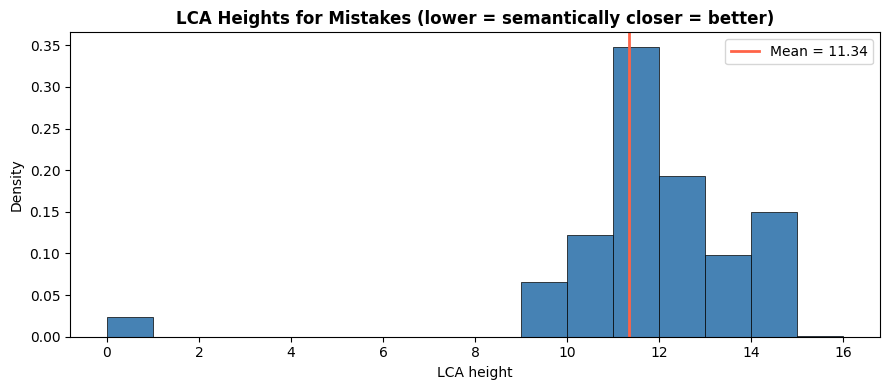

Saved baseline_lca_summary.json


In [ ]:
lca_df = pd.read_csv(os.path.join(SAVE_DIR, 'lca_matrix.csv'), index_col=0)
lca_df.columns = lca_df.columns.astype(int)
lca_df.index   = lca_df.index.astype(int)

# Predictions are 0-indexed; LCA matrix uses 1-indexed class IDs
preds_1  = [p + 1 for p in final['preds']]
labels_1 = [l + 1 for l in final['labels']]

lca_scores = []
for p, l in zip(preds_1, labels_1):
    if p != l and l in lca_df.index and p in lca_df.columns:
        h = lca_df.loc[l, p]
        if h >= 0:
            lca_scores.append(h)

lca_arr = np.array(lca_scores)

print('=' * 55)
print('Baseline CBM - Hierarchy-Aware Mistake Severity')
print('=' * 55)
print(f'  Mistakes          : {len(lca_scores)}')
print(f'  Mean LCA height   : {lca_arr.mean():.4f}  (lower = better)')
print(f'  Median LCA height : {np.median(lca_arr):.4f}')
print(f'  Std  LCA height   : {lca_arr.std():.4f}')

lca_bins = {
    'near (LCA ≤ 5)':    [h for h in lca_arr if h <= 5],
    'mid (6 ≤ LCA ≤ 8)':  [h for h in lca_arr if 6 <= h <= 8],
    'far (LCA > 8)':   [h for h in lca_arr if h > 8],
}

print('\nError for semantic severity:')
for label_bin, vals in lca_bins.items():
    pct = len(vals) / len(lca_arr) * 100
    print(f'  {label_bin:25s}: {len(vals):4d} errori ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lca_arr,
        bins=range(int(lca_arr.min()), int(lca_arr.max()) + 2),
        color='steelblue', edgecolor='black', linewidth=0.5, density=True)
ax.axvline(lca_arr.mean(), color='tomato', linewidth=2,
           label=f'Mean = {lca_arr.mean():.2f}')
ax.set_title('LCA Heights for Mistakes (lower = semantically closer = better)',
             fontweight='bold')
ax.set_xlabel('LCA height'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'baseline_lca_distribution.png'), dpi=150)
plt.show()

lca_summary = {
    'model':      'baseline_cbm',
    'n_concepts': N_CONCEPTS,
    'n_mistakes': len(lca_scores),
    'mean_lca':   float(lca_arr.mean()),
    'median_lca': float(np.median(lca_arr)),
    'std_lca':    float(lca_arr.std()),
}
with open(os.path.join(SAVE_DIR, 'baseline_lca_summary.json'), 'w') as f:
    json.dump(lca_summary, f, indent=2)
print('Saved baseline_lca_summary.json')